#   LangGraph 활용 - Self RAG 

### **학습 목표:** 

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [28]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [29]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings("ignore")

`(3) langfuase handler 설정`

In [30]:
# langfuse handler 설정 (선택적)
# langfuse는 LLM 추적/모니터링 도구입니다. 없어도 실습 진행 가능합니다.

try:
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()
    print("✅ Langfuse 핸들러 설정 완료")
except Exception as e:
    print(f"⚠️ Langfuse 설정 건너뜀 (선택사항): {e}")
    langfuse_handler = None
    print("💡 Langfuse 없이 실습을 진행합니다.")

✅ Langfuse 핸들러 설정 완료


---

## **Self-RAG**

- Self-RAG (Retrieval-Augmented Generation with Self-Reflection) 

- 주요 단계: 

   1. 검색 결정 (Retrieval Decision):
      - 입력: 질문 `x` 또는 질문 `x`와 생성된 답변 `y`
      - 목적: 검색기 `R`을 사용하여 `D` 개의 청크를 검색할지 결정
      - 출력: "yes", "no", "continue" 중 하나
      - 의미: 시스템이 추가 정보가 필요한지 판단

   2. 검색된 문서 관련성 평가:
      - 입력: 질문 `x`와 각 검색된 청크 `d`
      - 목적: 각 청크가 질문에 유용한 정보를 제공하는지 평가
      - 출력: "relevant" 또는 "irrelevant"
      - 의미: 관련 없는 정보를 필터링하여 품질을 향상

   3. 생성된 답변의 환각 평가:
      - 입력: 질문 `x`, 청크 `d`, 생성된 텍스트 `y`
      - 목적: 생성된 텍스트가 청크의 정보에 의해 지지되는지 평가
      - 출력: "fully supported", "partially supported", "no support"
      - 의미: 환각(hallucination)을 감지하고 정보의 신뢰성을 확인

   4. 생성된 답변의 유용성 평가:
      - 입력: 질문 `x`와 생성된 텍스트 `y`
      - 목적: 생성된 텍스트가 질문에 유용한 응답인지 평가
      - 출력: 5점 척도 (5: 매우 유용, 1: 전혀 유용하지 않음)
      - 의미: 응답의 품질과 관련성을 수치화

- 논문: https://arxiv.org/abs/2310.11511

### **1. 벡터저장소** 
- 메뉴 검색을 위해 저장해둔 저장소를 로드

In [31]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 인덱스 로드
vector_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="restaurant_menu",
    persist_directory="./chroma_db",
)

In [32]:
# 검색기 생성 
retriever= vector_db.as_retriever(search_kwargs={"k":3})

# 검색 테스트
query = "스테이크와 어울리는 와인을 추천해주세요."
results = retriever.invoke(query)

pprint(results)

[]


### **2. Retrieval Grader** 

- 검색 평가자는 **키워드 관련성**과 **의미적 관련성**을 기준으로 결과를 평가

- 평가는 **'yes/no' 이진법**으로 진행하며 불확실한 경우 'no' 처리

- 부분 관련성이나 맥락 정보도 **답변 형성 기여도** 기준으로 평가

`(1) 데이터 모델 및 LLM 초기화`

In [33]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnablePassthrough
from pydantic import BaseModel, Field
from typing import Literal


# 검색된 문서의 관련성 평가 결과를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: Literal['yes', 'no'] = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

`(2) LCEL 체인 구성`

In [34]:
# 문서 관련성 평가를 위한 시스템 프롬프트 정의
system_prompt = """당신은 사용자 질문에 대한 검색 결과의 관련성을 평가하는 전문가입니다.

평가 기준:
1. 키워드 관련성: 문서가 질문의 주요 단어나 유사어를 포함하는지 확인
2. 의미적 관련성: 문서의 전반적인 주제가 질문의 의도와 일치하는지 평가
3. 부분 관련성: 질문의 일부를 다루거나 맥락 정보를 제공하는 문서도 고려
4. 답변 가능성: 직접적인 답이 아니더라도 답변 형성에 도움될 정보 포함 여부 평가

점수 체계:
- 관련 있으면 'yes', 없으면 'no'로 평가
- 확실하지 않은 경우 'no'로 평가하여 불포함 쪽으로 결정

주의사항:
- 단순 단어 매칭이 아닌 질문의 전체 맥락을 고려하세요
- 완벽한 답변이 아니어도 유용한 정보가 있다면 관련 있다고 판단하세요

당신의 평가는 정보 검색 시스템 개선에 중요합니다. 균형 잡힌 평가를 해주세요."""

human_prompt = """
다음 문서가 사용자 질문에 관련 있는지 평가해주세요.

[Retrieved document]
{document}

[User question]
{question}

[Grade the relevance of the retrieved document]
"""

# 채점 프롬프트 템플릿 생성
grade_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", human_prompt),
])


# Retrieval Grader 파이프라인 구성
retrieval_grader = grade_prompt | structured_llm_grader

`(3) 평가 수행`

In [35]:
# 관련성 평가 실행
question = "이 식당을 대표하는 메뉴는 무엇인가요?"
retrieved_docs = vector_db.similarity_search(question, k=2)
print(f"검색된 문서 수: {len(retrieved_docs)}")
print("===============================================================================")
print()


relevant_docs = []

for doc in retrieved_docs:
    print("문서:", doc.page_content)
    print("---------------------------------------------------------------------------")

    relevance = retrieval_grader.invoke(
        input={"question": question, "document": doc},
        config={
            "callbacks": [langfuse_handler],
            "tags":["self-rag", "relevance-grader"],
        }
        )
    print(f"문서 관련성: {relevance}")

    if relevance.binary_score == 'yes':
        relevant_docs.append(doc)
    
    print("===========================================================================")

검색된 문서 수: 0



---
### **[실습]**

- 프롬프트를 개선하여 문서 관련성 평가기를 재구성합니다. 
- 샘플 데이터에 대한 문서 관련성 평가를 수행합니다. 

In [36]:
# 여기에 코드를 작성하세요.

### **3. Answer Generator** 

- **답변 생성** 시 문맥 내 정보만 사용하고 추측 배제
- 답변은 **직접 관련 정보**만 포함하여 간결하게 작성
- 정보 부족 시 "**주어진 정보만으로는 답할 수 없습니다**" 명시
- 필요시 **직접 인용문** 활용하여 정확성 확보

In [37]:
# 기본 RAG 체인
from langchain_core.output_parsers import StrOutputParser

def generator_answer(question, docs):

    template = """
    Answer the question based solely on the given context. Do not use any external information or knowledge.

    [Instructions]
        1. 질문과 관련된 정보를 문맥에서 신중하게 확인합니다.
        2. 답변에 질문과 직접 관련된 정보만 사용합니다.
        3. 문맥에 명시되지 않은 내용에 대해 추측하지 않습니다.
        4. 불필요한 정보를 피하고, 답변을 간결하고 명확하게 작성합니다.
        5. 문맥에서 답을 찾을 수 없으면 "주어진 정보만으로는 답할 수 없습니다."라고 답변합니다.
        6. 적절한 경우 문맥에서 직접 인용하며, 따옴표를 사용합니다.

    [Context]
    {context}

    [Question]
    {question}

    [Answer]
    """

    prompt = ChatPromptTemplate.from_template(template)
    llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)    

    def format_docs(docs):
        return "\n\n".join([d.page_content for d in docs])
    
    rag_chain = prompt | llm | StrOutputParser()
    
    generation = rag_chain.invoke(
        {"context": format_docs(docs), "question": question},
        config={
            "callbacks": [langfuse_handler],
            "tags": ["self-rag", "answer-generator"],
            }
        )

    return generation


# 관령성 평가를 통과한 문서를 기반으로 질문에 대한 답변 생성
generation = generator_answer(question, docs=relevant_docs)
print(generation)

주어진 정보만으로는 답할 수 없습니다.


---
### **[실습]**

- 프롬프트를 개선하여 답변 생성기를 재구성합니다. 
- 샘플 데이터에 대한 테스트를 수행합니다. 

In [38]:
# 여기에 코드를 작성하세요.

### **4. Hallucination Grader** 

- **시스템 프롬프트**는 사실 기반 답변을 평가하는 전문가 역할을 정의함
- 평가는 **두 가지 기준**으로 진행: 사실 근거 시 'yes', 근거 부족 시 'no'

In [39]:
# 환각(Hallucination) 평가 결과를 위한 데이터 모델 정의
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)


# 환각 평가를 위한 시스템 프롬프트 정의
system_prompt = """
You are an expert evaluator assessing whether an LLM-generated answer is grounded in and supported by a given set of facts.

[Your task]
    - LLM이 생성한 답변을 검토합니다.
    - 답변이 주어진 사실로 완전히 뒷받침되는지 판단합니다.

[Evaluation criteria]
    - 답변에 주어진 사실이나 명확히 추론할 수 있는 정보 외의 내용이 없어야 합니다.
    - 답변의 모든 핵심 내용이 주어진 사실에서 비롯되어야 합니다.
    - 사실적 정확성에 집중하고, 글쓰기 스타일이나 완전성은 평가하지 않습니다.

[Scoring]
    - 'yes': 답변이 사실에 근거하고 완전히 지원되는 경우.
    - 'no': 답변에 사실에 근거하지 않은 정보나 주장이 포함된 경우.

Your evaluation is crucial in ensuring the reliability and factual accuracy of AI-generated responses. Be thorough and critical in your assessment.
"""

# 환각 평가 프롬프트 템플릿 생성
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "[Set of facts]\n{documents}\n\n[LLM generation]\n{generation}"),
    ]
)

# Hallucination Grader 파이프라인 구성
hallucination_grader = hallucination_prompt | structured_llm_grader

# 환각 평가 실행
hallucination = hallucination_grader.invoke(
    {"documents": relevant_docs, "generation": generation},
    config={
        "callbacks": [langfuse_handler],
        "tags": ["self-rag", "hallucination-grader"],
    }
    )
print(f"환각 평가: {hallucination}")

환각 평가: binary_score='yes'


---
### **[실습]**

- 프롬프트를 개선하여 환각 평가기를 재구성합니다. 
- 샘플 데이터에 대한 테스트를 수행합니다. 

In [40]:
# 여기에 코드를 작성하세요.

### **5. Answer Grader** 

- 답변 평가는 **정보 포함 여부**를 기준으로 'yes' 또는 'no'로 판단
- 시스템은 **단순명확한 기준**으로 답변의 적절성을 평가함

In [41]:
# 답변 평가 결과를 위한 데이터 모델 정의
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


# LLM 모델 초기화 및 구조화된 출력 설정
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# 답변 평가를 위한 시스템 프롬프트 정의
system_prompt = """
You are an expert evaluator tasked with assessing whether an LLM-generated answer effectively addresses and resolves a user's question.

[Your task]
    - 사용자의 질문을 신중히 분석하여 핵심 의도와 요구 사항을 이해합니다.
    - LLM이 생성한 답변이 질문을 충분히 해결했는지 판단합니다.

[Evaluation criteria]
    - 관련성: 답변이 질문과 직접적으로 관련되어야 합니다.
    - 완전성: 질문의 모든 측면이 다뤄져야 합니다.
    - 정확성: 제공된 정보가 정확하고 최신이어야 합니다.
    - 명확성: 답변이 명확하고 이해하기 쉬워야 합니다.
    - 구체성: 질문의 요구 사항에 맞는 상세한 답변이어야 합니다.

[Scoring]
    - 'yes': 답변이 질문을 효과적으로 해결한 경우.
    - 'no': 답변이 질문을 충분히 해결하지 못하거나 중요한 요소가 부족한 경우.
    - 답변이 완벽하지 않아도 핵심 질문을 해결하면 'yes'를 줄 수 있습니다.
    - 부분적으로 맞지만 중요한 요소가 빠진 답변은 'no'로 평가합니다.

Your evaluation plays a critical role in ensuring the quality and effectiveness of AI-generated responses. Strive for balanced and thoughtful assessments.
"""


# 답변 평가 프롬프트 템플릿 생성
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "[User question]\n{question}\n\n[LLM generation]\n{generation}"),
    ]
)


# Answer Grader 파이프라인 구성
answer_grader = answer_prompt | structured_llm_grader

# 답변 평가 실행
print("Question:", question)
print("Generation:", generation)

answer_score = answer_grader.invoke(
    {"question": question, "generation": generation},
    config={
        "callbacks": [langfuse_handler],
        "tags": ["self-rag", "answer-grader"],
        }
)
print(f"답변 평가: {answer_score}")

Question: 이 식당을 대표하는 메뉴는 무엇인가요?
Generation: 주어진 정보만으로는 답할 수 없습니다.
답변 평가: binary_score='yes'


---
### **[실습]**

- 프롬프트를 개선하여 답변 평가기를 재구성합니다. 
- 샘플 데이터에 대한 테스트를 수행합니다. 

In [42]:
# 여기에 코드를 작성하세요.

### **6. Question Re-writer** 

- 질문을 **명확성과 간결성** 중심으로 개선하는 것이 주요 목표
- 불필요한 정보 제거 시에도 **원래 의도 유지**가 핵심 지침

In [43]:
def rewrite_question(question: str) -> str:
    """
    주어진 질문을 벡터 저장소 검색에 최적화된 형태로 다시 작성합니다.

    :param question: 원본 질문 문자열
    :return: 다시 작성된 질문 문자열
    """
    # LLM 모델 초기화
    llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

    # 시스템 프롬프트 정의
    system_prompt = """
    You are an expert question re-writer. Your task is to convert input questions into optimized versions 
    for vectorstore retrieval. Analyze the input carefully and focus on capturing the underlying semantic 
    intent and meaning. Your goal is to create a question that will lead to more effective and relevant 
    document retrieval.

    [Guidelines]
        1. 질문에서 핵심 개념과 주요 대상을 식별하고 강조합니다.
        2. 약어나 모호한 용어를 풀어서 사용합니다.
        3. 관련 문서에 등장할 수 있는 동의어나 연관된 용어를 포함합니다.
        4. 질문의 원래 의도와 범위를 유지합니다.
        5. 복잡한 질문은 간단하고 집중된 하위 질문으로 나눕니다.

    Remember, the goal is to improve retrieval effectiveness, not to change the fundamental meaning of the question.
    """

    # 질문 다시 쓰기 프롬프트 템플릿 생성
    re_write_prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system_prompt),
            (
                "human",
                "[Initial question]\n{question}\n\n[Improved question]\n",
            ),
        ]
    )

    # 질문 다시 쓰기 체인 구성
    question_rewriter = re_write_prompt | llm | StrOutputParser()

    # 질문 다시 쓰기 실행
    rewritten_question = question_rewriter.invoke(
        {"question": question},
        config={
            "callbacks": [langfuse_handler],
            "tags": ["self-rag", "question-rewriter"],
        },
    )

    return rewritten_question

# 질문 다시 쓰기 테스트
rewritten_question = rewrite_question(question)
print(f"원본 질문: {question}")
print(f"다시 쓴 질문: {rewritten_question}")

원본 질문: 이 식당을 대표하는 메뉴는 무엇인가요?
다시 쓴 질문: 이 식당을 대표하는 인기 메뉴와 주요 요리 종류는 무엇인가요?


In [44]:
# 다시 쓴 질문을 사용하여 벡터 저장소에서 문서 검색
query = rewritten_question
retrieved_docs = vector_db.similarity_search(query, k=2)
print(len(retrieved_docs))
print("===========================================================================")

for doc in retrieved_docs:
    print("문서:", doc.page_content)
    print("---------------------------------------------------------------------------")

0


---
### **[실습]**

- 프롬프트를 개선하여 검색어 변환기를 재구성합니다. 
- 샘플 데이터에 대한 테스트를 수행합니다. 

In [45]:
# 여기에 코드를 작성하세요.

### **7. LangGraph로 그래프 구현** 

- **LangGraph** 구현은 기본적인 StateGraph를 활용
- **Node와 Edge** 를 사용하여, 이전에 구현한 노드 함수를 연결

`(1) 그래프 State 생성`

In [46]:
from typing import List, TypedDict
from langchain_core.documents import Document

class GraphState(TypedDict):
    question: str                 # 사용자의 질문
    generation: str               # LLM 생성 답변
    documents: List[Document]     # 컨텍스트 문서 (검색된 문서)
    num_generations: int          # 질문 or 답변 생성 횟수 (무한 루프 방지에 활용)

`(2) Node 구성`

In [47]:
# Node 정의

def retrieve(state: GraphState) -> GraphState:
    """문서를 검색하는 함수"""
    print("--- 문서 검색 ---")
    question = state["question"]
    
    # 문서 검색 로직
    documents = vector_db.similarity_search(question)
    return {"documents": documents}      # 가장 마지막에 검색한 문서 객체들로 상태를 업데이트 

def generate(state: GraphState) -> GraphState:
    """답변을 생성하는 함수"""
    print("--- 답변 생성 ---")
    question = state["question"]
    documents = state["documents"]
    
    # RAG를 이용한 답변 생성
    generation = generator_answer(question, docs=documents)

    # 생성 횟수 업데이트
    num_generations = state.get("num_generations", 0)
    num_generations += 1
    return {"generation": generation, "num_generations": num_generations}      # 답변, 생성횟수 업데이트 


def grade_documents(state: GraphState) -> GraphState:
    """검색된 문서의 관련성을 평가하는 함수"""
    print("--- 문서 관련성 평가 ---")
    question = state["question"]
    documents = state["documents"]
    
    # 각 문서 평가
    filtered_docs = []
    for d in documents:
        score = retrieval_grader.invoke({"question": question, "document": d})
        grade = score.binary_score
        if grade == "yes":
            print("---문서 관련성: 있음---")
            filtered_docs.append(d)
        else:
            print("---문서 관련성: 없음---")
            
    return {"documents": filtered_docs}       # 관련성 평가에 합격한 문서들만 저장 (override)



def transform_query(state: GraphState) -> GraphState:
    """질문을 개선하는 함수"""
    print("--- 질문 개선 ---")
    question = state["question"]
    
    # 질문 재작성
    rewritten_question = rewrite_question(question)

    # 생성 횟수 업데이트
    num_generations = state.get("num_generations", 0)
    num_generations += 1
    return {"question": rewritten_question, "num_generations": num_generations}      # 재작성한 질문을 저장, 생성횟수 업데이트 

`(3) Edge 구성`

In [48]:
def decide_to_generate(state: GraphState) -> str:
    """답변 생성 여부를 결정하는 함수"""

    num_generations = state.get("num_generations", 0)
    if num_generations > 2:
        print("--- 결정: 생성 횟수 초과, 답변 생성 (-> generate)---")
        return "generate"


    print("--- 평가된 문서 분석 ---")
    filtered_documents = state["documents"]
    
    if not filtered_documents:
        print("--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---")
        return "transform_query"
    else:
        print("--- 결정: 답변 생성 (-> generate)---")
        return "generate"



def grade_generation(state: GraphState) -> str:
    """생성된 답변의 품질을 평가하는 함수"""

    num_generations = state.get("num_generations", 0)
    if num_generations > 2:
        print("--- 결정: 생성 횟수 초과, 종료 (-> END)---")
        return "end"
    
    # 1단계: 환각 여부 확인
    print("--- 환각 여부 확인 ---")
    question, documents, generation = state["question"], state["documents"], state["generation"]
    
    
    hallucination_grade = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )

    if hallucination_grade.binary_score == "yes":
        print("--- 결정: No 환각 (답변이 컨텍스트에 근거함) ---")

        # 1단계 통과할 경우 -> 2단계: 질문-답변 관련성 평가 
        print("---질문-답변 관련성 확인---")
        relevance_grade = answer_grader.invoke({"question": question, "generation": generation})
        if relevance_grade.binary_score == "yes":
            print("--- 결정: 생성된 답변이 질문을 잘 다룸 (-> END) ---")
            return "useful"
        else:
            print("--- 결정: 생성된 답변이 질문을 제대로 다루지 않음 (-> transform_query) ---")
            return "not useful"
    else:
        print("--- 결정: 생성된 답변이 문서에 근거하지 않음, 재시도 필요 (-> generate) ---")
        return "not supported"

`(4) 그래프 연결`

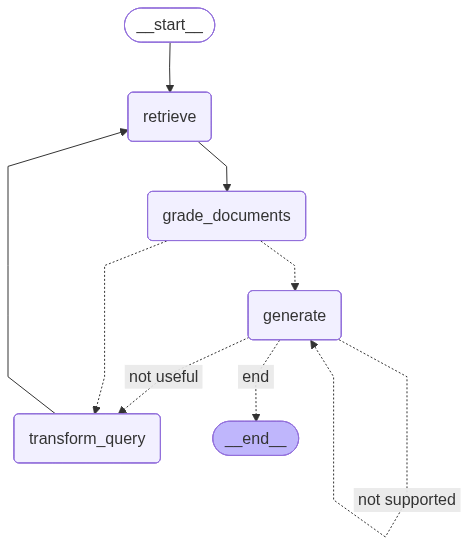

In [49]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# 워크플로우 그래프 초기화
builder = StateGraph(GraphState)

# 노드 정의
builder.add_node("retrieve", retrieve)                # 문서 검색
builder.add_node("grade_documents", grade_documents)  # 문서 평가
builder.add_node("generate", generate)                # 답변 생성
builder.add_node("transform_query", transform_query)  # 질문 개선

# 그래프 구축
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "grade_documents")

# 조건부 엣지 추가: 문서 평가 후 결정
builder.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
builder.add_edge("transform_query", "retrieve")

# 조건부 엣지 추가: 답변 생성 후 평가
builder.add_conditional_edges(
    "generate",
    grade_generation,
    {
        "not supported": "generate",          # 환각이 발생한 경우 -> 답변을 다시 생성 
        "not useful": "transform_query",      # 질문과 답변의 관련성이 부족한 경우 -> 쿼리 개선해서 다시 검색 
        "useful": END, 
        "end": END,
    },
)

# 그래프 컴파일
graph = builder.compile()

# 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

`(5) 그래프 실행`

In [50]:
inputs = {"question": "이 식당의 대표 메뉴는 무엇인가요? 주재료는 무엇인가요?"}
final_output = graph.invoke(inputs,
                            config={
                                "callbacks": [langfuse_handler], 
                                "tags": ["self-rag", "workflow"]
                                },
                        )

--- 문서 검색 ---
--- 문서 관련성 평가 ---
--- 평가된 문서 분석 ---
--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---
--- 질문 개선 ---
--- 문서 검색 ---
--- 문서 관련성 평가 ---
--- 평가된 문서 분석 ---
--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---
--- 질문 개선 ---
--- 문서 검색 ---
--- 문서 관련성 평가 ---
--- 평가된 문서 분석 ---
--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---
--- 질문 개선 ---
--- 문서 검색 ---
--- 문서 관련성 평가 ---
--- 결정: 생성 횟수 초과, 답변 생성 (-> generate)---
--- 답변 생성 ---
--- 결정: 생성 횟수 초과, 종료 (-> END)---


In [51]:
# 최종 답변 
final_output["generation"]

'주어진 정보만으로는 답할 수 없습니다.'

In [52]:
inputs = {"question": "김치찌개 메뉴가 있나요?"}
for output in graph.stream(inputs,
                            config={
                                "callbacks": [langfuse_handler],
                                "tags": ["self-rag", "workflow"]
                                },
                        ):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

--- 문서 검색 ---
"Node 'retrieve':"
"Value: {'documents': []}"

----------------------------------------------------------

--- 문서 관련성 평가 ---
--- 평가된 문서 분석 ---
--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---
"Node 'grade_documents':"
"Value: {'documents': []}"

----------------------------------------------------------

--- 질문 개선 ---
"Node 'transform_query':"
("Value: {'question': '한국 음식점에서 김치찌개 메뉴가 제공되는지, 김치찌개 요리의 종류와 특징에 대해 알려주세요.', "
 "'num_generations': 1}")

----------------------------------------------------------

--- 문서 검색 ---
"Node 'retrieve':"
"Value: {'documents': []}"

----------------------------------------------------------

--- 문서 관련성 평가 ---
--- 평가된 문서 분석 ---
--- 결정: 모든 문서가 질문과 관련이 없음, 질문 개선 필요 (-> transform_query)---
"Node 'grade_documents':"
"Value: {'documents': []}"

----------------------------------------------------------

--- 질문 개선 ---
"Node 'transform_query':"
("Value: {'question': '한국 음식점에서 제공되는 김치찌개 메뉴의 유무와 김치찌개의 다양한 종류, 각 종류별 조리 방법과 "
 "특징에 대해 설명해 

In [53]:
# 최종 답변
print(value["generation"])

주어진 정보만으로는 답할 수 없습니다.


---
### **[실습]**

- State, Node, Edge를 직접 구성하여, Self RAG 시스템을 구현합니다. 
- 그래프 구현을 통해 RAG 품질을 개선하는 과정을 이해합니다.
- 데이터:
    - data/housing_leasing_law.pdf
    - data/labor_law.pdf
    - data/personal_info_law.pdf

총 로드된 문서 수: 71
분할된 청크 수: 200
✅ 벡터 DB 생성 완료
✅ Retrieval Grader 구성 완료
✅ Answer Generator 구성 완료
✅ Hallucination Grader 구성 완료
✅ Answer Grader 구성 완료
✅ Question Re-writer 구성 완료

🏗️ LangGraph 구축 중...
✅ LangGraph 구축 완료



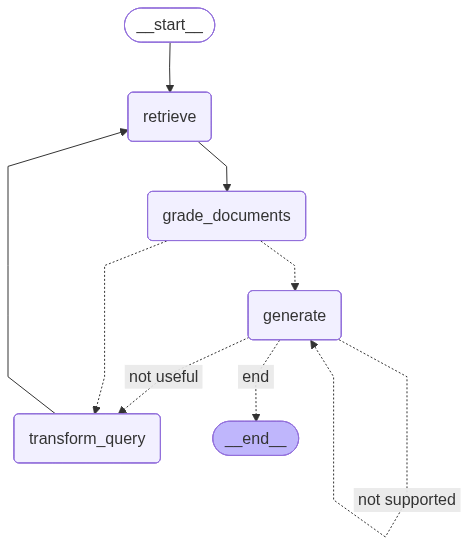

법률 Self-RAG 시스템 테스트

[테스트 1] 주택임대차 관련 질문
--------------------------------------------------------------------------------
🔍 법률 문서 검색 중...
📋 법률 문서 관련성 평가 중...
  ✅ 관련 문서 발견
  ✅ 관련 문서 발견
  ❌ 관련 없는 문서
  ❌ 관련 없는 문서
  ❌ 관련 없는 문서
📊 관련 문서: 2/5
✅ 관련 문서 존재 → 답변 생성
💡 법률 답변 생성 중...
🔍 환각 여부 검사 중...
✅ 환각 없음 (문서 기반 답변)
🔍 답변 유용성 평가 중...
✅ 유용한 답변 → 종료

[최종 답변]
전세 계약 시 보증금을 보호받으려면 다음과 같은 절차를 따라야 합니다.

1. **우선변제권 확보**: 임차인은 보증금 중 일정액을 다른 담보물권자보다 우선하여 변제받을 권리가 있습니다(제8조 제1항). 이를 위해서는 주택에 대한 경매신청의 등기 전에 제3조 제1항의 요건을 갖추어야 합니다.

2. **주택임대차위원회의 심의**: 우선변제를 받을 임차인 및 보증금 중 일정액의 범위와 기준은 제8조의2에 따른 주택임대차위원회의 심의를 거쳐 대통령령으로 정해집니다(제8조 제3항).

따라서, 임차인은 경매신청 등기 전에 필요한 요건을 갖추고, 주택임대차위원회의 심의를 통해 보증금 보호를 위한 절차를 진행해야 합니다.

[테스트 2] 근로 관련 질문
--------------------------------------------------------------------------------
🔍 법률 문서 검색 중...
📋 법률 문서 관련성 평가 중...
  ❌ 관련 없는 문서
  ✅ 관련 문서 발견
  ✅ 관련 문서 발견
  ✅ 관련 문서 발견
  ✅ 관련 문서 발견
📊 관련 문서: 4/5
✅ 관련 문서 존재 → 답변 생성
💡 법률 답변 생성 중...
🔍 환각 여부 검사 중...
✅ 환각 없음 (문서 기반 답변)
🔍 답변 유용성 평가 중...
✅ 유용한 답

In [55]:
# ============================================================================
# 실습: 법률 문서용 Self-RAG 시스템 구현
# ============================================================================

# ----------------------------------------------------------------------------
# 1. PDF 문서 로드 및 벡터 DB 생성
# ----------------------------------------------------------------------------

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter  # 수정된 import
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

# PDF 파일 로드
pdf_files = [
    "data/housing_leasing_law.pdf",
    "data/labor_law.pdf", 
    "data/personal_info_law.pdf"
]

all_documents = []
for pdf_file in pdf_files:
    loader = PyPDFLoader(pdf_file)
    documents = loader.load()
    all_documents.extend(documents)

print(f"총 로드된 문서 수: {len(all_documents)}")

# 텍스트 분할
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
)
splits = text_splitter.split_documents(all_documents)
print(f"분할된 청크 수: {len(splits)}")

# 임베딩 모델 및 벡터 DB 생성
embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

law_vector_db = Chroma.from_documents(
    documents=splits,
    embedding=embeddings_model,
    collection_name="law_documents",
    persist_directory="./chroma_db_law",
)

print("✅ 벡터 DB 생성 완료")

# ----------------------------------------------------------------------------
# 2. Retrieval Grader (법률 문서용 프롬프트 개선)
# ----------------------------------------------------------------------------

from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import Literal

class LawGradeDocuments(BaseModel):
    """법률 문서 관련성 평가 결과"""
    binary_score: Literal['yes', 'no'] = Field(
        description="법률 문서가 질문과 관련 있는지 'yes' 또는 'no'"
    )

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
law_retrieval_llm = llm.with_structured_output(LawGradeDocuments)

law_retrieval_system = """당신은 법률 문서 검색 결과의 관련성을 평가하는 법률 정보 전문가입니다.

평가 기준:
1. 법률 조항 관련성: 문서가 질문과 관련된 법률 조항이나 규정을 포함하는지 확인
2. 법적 개념 일치성: 질문에서 다루는 법적 개념(권리, 의무, 절차 등)과 일치하는지 평가
3. 적용 범위: 해당 법률이 질문 상황에 적용 가능한지 판단
4. 법률 용어: 질문의 법률 용어와 관련된 내용이 포함되어 있는지 확인

점수 체계:
- 관련 있으면 'yes', 없으면 'no'로 평가
- 법률 조항이나 규정이 직접 관련되면 'yes'
- 일반적인 법률 설명이지만 질문과 무관하면 'no'

법률 정보의 정확성은 매우 중요하므로 신중하게 평가해주세요."""

law_retrieval_prompt = ChatPromptTemplate.from_messages([
    ("system", law_retrieval_system),
    ("human", "[검색된 법률 문서]\n{document}\n\n[사용자 질문]\n{question}\n\n[관련성 평가]")
])

law_retrieval_grader = law_retrieval_prompt | law_retrieval_llm

print("✅ Retrieval Grader 구성 완료")

# ----------------------------------------------------------------------------
# 3. Answer Generator (법률 문서용 프롬프트 개선)
# ----------------------------------------------------------------------------

from langchain_core.output_parsers import StrOutputParser

def law_generator_answer(question, docs):
    """법률 문서 기반 답변 생성"""
    
    template = """당신은 법률 전문가로서 주어진 법률 문서를 기반으로 질문에 답변합니다.

[지침]
1. 법률 문서에 명시된 조항과 규정만을 근거로 답변합니다.
2. 법률 조항 번호와 내용을 정확하게 인용합니다.
3. 법률 용어를 정확하게 사용하되, 필요시 쉽게 설명을 추가합니다.
4. 추측이나 일반적인 법률 상식이 아닌, 문서 내 정보만 사용합니다.
5. 문서에서 답을 찾을 수 없으면 "주어진 법률 문서만으로는 답할 수 없습니다"라고 답변합니다.
6. 법률 조항을 인용할 때는 조항 번호와 함께 정확히 인용합니다.

[법률 문서]
{context}

[질문]
{question}

[답변]
"""
    
    prompt = ChatPromptTemplate.from_template(template)
    llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    
    def format_docs(docs):
        return "\n\n".join([d.page_content for d in docs])
    
    rag_chain = prompt | llm | StrOutputParser()
    
    # langfuse_handler가 None일 경우 처리
    config = {"tags": ["self-rag", "law-answer-generator"]}
    if langfuse_handler is not None:
        config["callbacks"] = [langfuse_handler]
    
    generation = rag_chain.invoke(
        {"context": format_docs(docs), "question": question},
        config=config
    )
    
    return generation

print("✅ Answer Generator 구성 완료")

# ----------------------------------------------------------------------------
# 4. Hallucination Grader (법률 문서용 프롬프트 개선)
# ----------------------------------------------------------------------------

class LawGradeHallucinations(BaseModel):
    """법률 답변 환각 평가 결과"""
    binary_score: str = Field(
        description="답변이 법률 문서에 근거하는지 'yes' 또는 'no'"
    )

law_hallucination_llm = llm.with_structured_output(LawGradeHallucinations)

law_hallucination_system = """당신은 법률 정보의 정확성을 검증하는 전문가입니다.

[평가 작업]
- LLM이 생성한 법률 답변이 주어진 법률 문서에 완전히 근거하는지 평가합니다.
- 법률 조항, 규정, 절차 등이 문서 내용과 일치하는지 확인합니다.

[평가 기준]
- 답변의 모든 법률 정보가 주어진 문서에서 확인 가능해야 합니다.
- 법률 조항 번호와 내용이 정확히 일치해야 합니다.
- 해석이나 추론도 문서 내용에서 명확히 도출 가능해야 합니다.
- 일반적인 법률 상식이 아닌, 문서 기반 정보인지 확인합니다.

[점수 체계]
- 'yes': 답변이 법률 문서에 완전히 근거하는 경우
- 'no': 답변에 문서에 없는 정보나 잘못된 인용이 포함된 경우

법률 정보의 정확성은 매우 중요하므로 엄격하게 평가해주세요."""

law_hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system", law_hallucination_system),
    ("human", "[법률 문서]\n{documents}\n\n[생성된 답변]\n{generation}\n\n[평가]")
])

law_hallucination_grader = law_hallucination_prompt | law_hallucination_llm

print("✅ Hallucination Grader 구성 완료")

# ----------------------------------------------------------------------------
# 5. Answer Grader (법률 문서용 프롬프트 개선)
# ----------------------------------------------------------------------------

class LawGradeAnswer(BaseModel):
    """법률 답변 유용성 평가 결과"""
    binary_score: str = Field(
        description="답변이 질문에 적절한지 'yes' 또는 'no'"
    )

law_answer_llm = llm.with_structured_output(LawGradeAnswer)

law_answer_system = """당신은 법률 답변의 유용성을 평가하는 전문가입니다.

[평가 작업]
- 생성된 답변이 사용자의 법률 질문을 충분히 해결하는지 평가합니다.

[평가 기준]
- 관련성: 답변이 질문의 법률적 쟁점과 직접 관련되는지
- 완전성: 질문에서 요구하는 법률 정보를 모두 제공하는지
- 명확성: 법률 조항과 규정이 명확하게 설명되어 있는지
- 실용성: 답변이 질문자에게 실질적으로 도움이 되는지

[점수 체계]
- 'yes': 답변이 질문을 효과적으로 해결하는 경우
- 'no': 답변이 불완전하거나 질문의 핵심을 다루지 않는 경우

법률 정보의 유용성은 질문자의 권리 행사에 직결되므로 신중하게 평가해주세요."""

law_answer_prompt = ChatPromptTemplate.from_messages([
    ("system", law_answer_system),
    ("human", "[사용자 질문]\n{question}\n\n[생성된 답변]\n{generation}\n\n[평가]")
])

law_answer_grader = law_answer_prompt | law_answer_llm

print("✅ Answer Grader 구성 완료")

# ----------------------------------------------------------------------------
# 6. Question Re-writer (법률 문서용 프롬프트 개선)
# ----------------------------------------------------------------------------

def law_rewrite_question(question: str) -> str:
    """법률 질문을 검색에 최적화된 형태로 재작성"""
    
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    
    system_prompt = """당신은 법률 질문을 검색에 최적화하는 전문가입니다.

[재작성 지침]
1. 질문에서 핵심 법률 개념과 용어를 식별합니다.
2. 구어체나 일상 용어를 법률 용어로 변환합니다.
3. 관련 법률 조항이나 규정과 연결될 수 있는 키워드를 추가합니다.
4. 복잡한 질문은 핵심 법률 쟁점으로 단순화합니다.
5. 질문의 법률적 의도와 범위는 유지합니다.

예시:
- "집주인이 보증금을 안 돌려줘요" → "주택임대차보호법 보증금 반환 의무 및 절차"
- "회사에서 해고당했는데 부당한 것 같아요" → "근로기준법 부당해고 요건 및 구제절차"

목표는 법률 문서 검색의 정확성을 높이는 것입니다."""
    
    re_write_prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "[원본 질문]\n{question}\n\n[개선된 질문]")
    ])
    
    question_rewriter = re_write_prompt | llm | StrOutputParser()
    
    # langfuse_handler가 None일 경우 처리
    config = {"tags": ["self-rag", "law-question-rewriter"]}
    if langfuse_handler is not None:
        config["callbacks"] = [langfuse_handler]
    
    rewritten_question = question_rewriter.invoke(
        {"question": question},
        config=config
    )
    
    return rewritten_question

print("✅ Question Re-writer 구성 완료")

# ----------------------------------------------------------------------------
# 7. LangGraph 구성 - State, Node, Edge
# ----------------------------------------------------------------------------

from typing import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END

# (1) State 정의
class LawGraphState(TypedDict):
    question: str                 # 사용자 질문
    generation: str               # LLM 생성 답변
    documents: List[Document]     # 검색된 법률 문서
    num_generations: int          # 생성 횟수 (무한 루프 방지)

# (2) Node 함수 정의
def law_retrieve(state: LawGraphState) -> LawGraphState:
    """법률 문서 검색"""
    print("🔍 법률 문서 검색 중...")
    question = state["question"]
    documents = law_vector_db.similarity_search(question, k=5)
    return {"documents": documents}

def law_grade_documents(state: LawGraphState) -> LawGraphState:
    """검색된 법률 문서 관련성 평가"""
    print("📋 법률 문서 관련성 평가 중...")
    question = state["question"]
    documents = state["documents"]
    
    filtered_docs = []
    for doc in documents:
        # langfuse_handler가 None일 경우 처리
        config = {"tags": ["self-rag", "law-retrieval-grader"]}
        if langfuse_handler is not None:
            config["callbacks"] = [langfuse_handler]
        
        score = law_retrieval_grader.invoke(
            {"question": question, "document": doc},
            config=config
        )
        if score.binary_score == "yes":
            print("  ✅ 관련 문서 발견")
            filtered_docs.append(doc)
        else:
            print("  ❌ 관련 없는 문서")
    
    print(f"📊 관련 문서: {len(filtered_docs)}/{len(documents)}")
    return {"documents": filtered_docs}

def law_generate(state: LawGraphState) -> LawGraphState:
    """법률 답변 생성"""
    print("💡 법률 답변 생성 중...")
    question = state["question"]
    documents = state["documents"]
    
    generation = law_generator_answer(question, docs=documents)
    
    num_generations = state.get("num_generations", 0)
    num_generations += 1
    return {"generation": generation, "num_generations": num_generations}

def law_transform_query(state: LawGraphState) -> LawGraphState:
    """법률 질문 재작성"""
    print("🔄 법률 질문 재작성 중...")
    question = state["question"]
    
    rewritten_question = law_rewrite_question(question)
    print(f"  원본: {question}")
    print(f"  개선: {rewritten_question}")
    
    num_generations = state.get("num_generations", 0)
    num_generations += 1
    return {"question": rewritten_question, "num_generations": num_generations}

# (3) Edge 함수 정의
def law_decide_to_generate(state: LawGraphState) -> str:
    """답변 생성 여부 결정"""
    num_generations = state.get("num_generations", 0)
    if num_generations > 2:
        print("⚠️ 생성 횟수 초과 → 답변 생성")
        return "generate"
    
    filtered_documents = state["documents"]
    if not filtered_documents:
        print("⚠️ 관련 문서 없음 → 질문 재작성")
        return "transform_query"
    else:
        print("✅ 관련 문서 존재 → 답변 생성")
        return "generate"

def law_grade_generation(state: LawGraphState) -> str:
    """생성된 답변 품질 평가"""
    num_generations = state.get("num_generations", 0)
    if num_generations > 2:
        print("⚠️ 생성 횟수 초과 → 종료")
        return "end"
    
    # 환각 평가
    print("🔍 환각 여부 검사 중...")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    
    # langfuse_handler가 None일 경우 처리
    config_hall = {"tags": ["self-rag", "law-hallucination-grader"]}
    if langfuse_handler is not None:
        config_hall["callbacks"] = [langfuse_handler]
    
    hallucination_grade = law_hallucination_grader.invoke(
        {"documents": documents, "generation": generation},
        config=config_hall
    )
    
    if hallucination_grade.binary_score == "yes":
        print("✅ 환각 없음 (문서 기반 답변)")
        
        # 답변 유용성 평가
        print("🔍 답변 유용성 평가 중...")
        
        # langfuse_handler가 None일 경우 처리
        config_ans = {"tags": ["self-rag", "law-answer-grader"]}
        if langfuse_handler is not None:
            config_ans["callbacks"] = [langfuse_handler]
        
        relevance_grade = law_answer_grader.invoke(
            {"question": question, "generation": generation},
            config=config_ans
        )
        
        if relevance_grade.binary_score == "yes":
            print("✅ 유용한 답변 → 종료")
            return "useful"
        else:
            print("⚠️ 유용성 부족 → 질문 재작성")
            return "not useful"
    else:
        print("⚠️ 환각 감지 → 답변 재생성")
        return "not supported"

# (4) 그래프 구축
print("\n🏗️ LangGraph 구축 중...")
law_builder = StateGraph(LawGraphState)

# 노드 추가
law_builder.add_node("retrieve", law_retrieve)
law_builder.add_node("grade_documents", law_grade_documents)
law_builder.add_node("generate", law_generate)
law_builder.add_node("transform_query", law_transform_query)

# 엣지 연결
law_builder.add_edge(START, "retrieve")
law_builder.add_edge("retrieve", "grade_documents")

# 조건부 엣지
law_builder.add_conditional_edges(
    "grade_documents",
    law_decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
law_builder.add_edge("transform_query", "retrieve")

law_builder.add_conditional_edges(
    "generate",
    law_grade_generation,
    {
        "not supported": "generate",
        "not useful": "transform_query",
        "useful": END,
        "end": END,
    },
)

# 그래프 컴파일
law_graph = law_builder.compile()

print("✅ LangGraph 구축 완료\n")

# 그래프 시각화
from IPython.display import Image, display
display(Image(law_graph.get_graph().draw_mermaid_png()))

# ----------------------------------------------------------------------------
# 8. 테스트 실행
# ----------------------------------------------------------------------------

print("="*80)
print("법률 Self-RAG 시스템 테스트")
print("="*80)

# 테스트 질문 1: 주택임대차보호법
print("\n[테스트 1] 주택임대차 관련 질문")
print("-"*80)
test_question_1 = "전세 계약 시 보증금을 보호받으려면 어떻게 해야 하나요?"

# langfuse_handler가 None일 경우 처리
config_1 = {"tags": ["self-rag", "law-workflow", "test-1"]}
if langfuse_handler is not None:
    config_1["callbacks"] = [langfuse_handler]

result_1 = law_graph.invoke(
    {"question": test_question_1},
    config=config_1
)
print("\n[최종 답변]")
print(result_1["generation"])
print("="*80)

# 테스트 질문 2: 근로기준법
print("\n[테스트 2] 근로 관련 질문")
print("-"*80)
test_question_2 = "부당해고를 당했을 때 어떤 구제 방법이 있나요?"

# langfuse_handler가 None일 경우 처리
config_2 = {"tags": ["self-rag", "law-workflow", "test-2"]}
if langfuse_handler is not None:
    config_2["callbacks"] = [langfuse_handler]

result_2 = law_graph.invoke(
    {"question": test_question_2},
    config=config_2
)
print("\n[최종 답변]")
print(result_2["generation"])
print("="*80)

# 테스트 질문 3: 개인정보보호법
print("\n[테스트 3] 개인정보 관련 질문")
print("-"*80)
test_question_3 = "회사가 개인정보를 처리할 때 지켜야 할 원칙은 무엇인가요?"

# langfuse_handler가 None일 경우 처리
config_3 = {"tags": ["self-rag", "law-workflow", "test-3"]}
if langfuse_handler is not None:
    config_3["callbacks"] = [langfuse_handler]

result_3 = law_graph.invoke(
    {"question": test_question_3},
    config=config_3
)
print("\n[최종 답변]")
print(result_3["generation"])
print("="*80)

print("\n✅ 모든 테스트 완료!")
print("\n[실습 완료 요약]")
print("1. ✅ 법률 문서 PDF 로드 및 벡터 DB 생성")
print("2. ✅ Retrieval Grader 구성 (법률 문서용 프롬프트)")
print("3. ✅ Answer Generator 구성 (법률 답변용 프롬프트)")
print("4. ✅ Hallucination Grader 구성 (법률 정보 검증)")
print("5. ✅ Answer Grader 구성 (법률 답변 유용성)")
print("6. ✅ Question Re-writer 구성 (법률 용어 최적화)")
print("7. ✅ LangGraph State, Node, Edge 구성")
print("8. ✅ 3가지 법률 도메인 테스트 실행")
print("\n🎓 Self-RAG 시스템 학습 완료!")